In [3]:
import pandas as pd

log = pd.read_csv('/Users/francescameneghello/Downloads/simulated_log_test_only_sepsis_0.1.csv')

In [4]:
log

,Unnamed: 0,index,trace_id,activity,role,enabled_time,start_time,end_time,resource,prefix,...,DiagnosticXthorax,SIRSCritTemperature,DiagnosticUrinaryCulture,SIRSCritLeucos,Oligurie,DiagnosticLacticAcid,Diagnose,Hypoxie,DiagnosticUrinarySediment,DiagnosticECG
0,0,100,YE_CF,ER Registration,A,2014-12-07 04:56:30.236841,2014-12-07 02:58:09.440142,2014-12-07 05:02:34.470563,B,[],...,True,True,False,False,False,True,U,False,True,True
1,1,101,D_CF,ER Registration,A,2014-12-07 05:09:17.419472,2014-12-07 05:02:34.470563,2014-12-07 05:11:38.470563,A,[],...,True,True,False,False,False,True,U,False,True,True
2,2,102,QCA_CF,ER Registration,A,2014-12-07 06:30:22.361688,2014-12-07 05:02:34.470563,2014-12-07 06:43:09.440142,A,[],...,True,True,False,False,False,True,U,False,True,True
3,3,103,QCA_CF,ER Registration,A,2014-12-07 06:30:22.361688,2014-12-07 05:02:34.470563,2014-12-07 06:43:09.440142,A,[],...,True,True,False,False,False,True,U,False,True,True
4,4,104,QCA_CF,ER Registration,A,2014-12-07 06:30:22.361688,2014-12-07 05:02:34.470563,2014-12-07 06:43:09.440142,A,[],...,True,True,False,False,False,True,U,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843,2843,11861,FK_CF,Return ER,?,2016-11-19 00:16:41.470563,2016-11-26 15:20:36.470563,2016-11-27 04:45:44.470563,E,"['ER Registration', 'ER Triage', 'ER Sepsis Tr...",...,True,True,True,False,False,True,E,False,False,True
2844,2844,11862,FK_CF,Return ER,?,2016-11-19 00:16:41.470563,2016-11-27 04:45:44.470563,2016-11-27 12:37:14.470563,E,"['ER Registration', 'ER Triage', 'ER Sepsis Tr...",...,True,True,True,False,False,True,E,False,False,True
2845,2845,11863,FK_CF,Return ER,?,2016-11-19 00:16:41.470563,2016-11-27 12:37:14.470563,2016-11-28 05:57:32.470563,E,"['ER Registration', 'ER Triage', 'ER Sepsis Tr...",...,True,True,True,False,False,True,E,False,False,True
2846,2846,11864,FK_CF,Return ER,?,2016-11-19 00:16:41.470563,2016-11-28 05:57:32.470563,2016-11-28 14:47:47.470563,E,"['ER Registration', 'ER Triage', 'ER Sepsis Tr...",...,True,True,True,False,False,True,E,False,False,True


In [6]:
log['resource'].unique().tolist()

['B', 'A', 'B2', 'B1', 'M', 'N', 'E', 'K', 'P', 'L', 'C', '?', 'W']

In [7]:
def start_error(log):
    error = 0
    log['end_time'] = pd.to_datetime(log['end_time'])
    log['start_time'] = pd.to_datetime(log['start_time'])
    for index, row in log.iterrows():
        if row['start_time']>row['end_time']:
            error += 1
    return error

In [8]:
start_error(log)

0

In [11]:
### overlap

def overlap_error(log):
    log = log[log['resource'].notna()]
    res = log['resource'].unique().tolist()
    capacity = {r: 1 for r in res}
    overlap_error = 0
    resource_work = {r: {} for r in res}
    log['end_time'] = pd.to_datetime(log['end_time'])
    log['start_time'] = pd.to_datetime(log['start_time'])
    for index, row in log.iterrows():
        start = int(row['start_time'].timestamp())
        end = int(row['end_time'].timestamp())
        for i in range(start, end):
            if i in resource_work[row['resource']]:
                resource_work[row['resource']][i] += 1
                if resource_work[row['resource']][i] > capacity[row['resource']]:
                    overlap_error += 1
            else:
                resource_work[row['resource']][i] = 1
    return overlap_error

In [3]:
log = pd.read_csv('/Users/francescameneghello/Documents/GitHub/nirdizati-light/predictive_models_processing_time/sepsis_estimated_start.csv', sep=";")
log

,caseid,concept:name,org:resource,time:timestamp,lifecycle:transition,InfectionSuspected,DiagnosticBlood,DisfuncOrg,SIRSCritTachypnea,Hypotensie,...,Diagnose,Hypoxie,DiagnosticUrinarySediment,DiagnosticECG,Leucocytes,CRP,LacticAcid,available_time,enabled_time,start:timestamp
0,A,ER Registration,A,2014-10-22 12:15:41,complete,True,True,True,True,True,...,A,False,True,True,NaN,NaN,NaN,2014-10-22 07:37:09,NaN,2014-10-22 07:37:09
1,A,Leucocytes,B,2014-10-22 12:27:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.6,NaN,NaN,2014-10-22 10:00:00,NaN,2014-10-22 10:00:00
2,A,CRP,B,2014-10-22 12:27:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,21.0,NaN,2014-10-22 10:00:00,NaN,2014-10-22 10:00:00
3,A,LacticAcid,B,2014-10-22 12:27:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.2,2014-10-22 10:00:00,NaN,2014-10-22 10:00:00
4,A,ER Triage,C,2014-10-22 12:33:37,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-10-22 07:36:41,2014-10-22 12:15:41,2014-10-22 12:15:41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15185,ZZ,CRP,B,2014-11-14 08:00:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,146.0,NaN,2014-11-14 07:00:00,2014-11-12 18:07:00,2014-11-14 07:00:00
15186,ZZ,Leucocytes,B,2014-11-14 08:00:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,8.3,NaN,NaN,2014-11-14 07:00:00,2014-11-12 18:07:00,2014-11-14 07:00:00
15187,ZZ,Leucocytes,B,2014-11-16 08:00:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.7,NaN,NaN,2014-11-16 07:00:00,2014-11-14 08:00:00,2014-11-16 07:00:00
15188,ZZ,CRP,B,2014-11-16 08:00:00,complete,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,96.0,NaN,2014-11-16 07:00:00,2014-11-14 08:00:00,2014-11-16 07:00:00


In [33]:
import pandas as pd

log = pd.read_csv('/Users/francescameneghello/Documents/GitHub/nirdizati-light/predictive_models_processing_time/BPI_Challenge_2012_estimated_start.csv', sep=",")
start_times = []
log['start:timestamp'] = log['start:timestamp'].astype(str).str[:19]
log['start:timestamp'] = pd.to_datetime(log['start:timestamp'], utc=True, format="%Y-%m-%d %H:%M:%S")
caseid_unique = list(log['caseid'].unique())
for caseid in caseid_unique:
    group_case = log[log['caseid'] == caseid].sort_values(by='start:timestamp')
    start_times.append(group_case.iloc[0]['start:timestamp'])

/Users/francescameneghello/opt/anaconda3/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:719: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


[{'distribution': 'expon',
  'params': (0.0, 36028.060370009734),
  'ks_stat': 0.0323391371232246,
  'ks_pvalue': 0.2280824629001914},
 {'distribution': 'gamma',
  'params': (1.1351220305046046, -7.629257424890264, 31746.09251196276),
  'ks_stat': 0.03246128608506493,
  'ks_pvalue': 0.22440102788069227},
 {'distribution': 'beta',
  'params': (0.812975169918089,
   4.216676889365818,
   -1.6439943006143093e-25,
   237757.90893969656),
  'ks_stat': 0.05214093270626319,
  'ks_pvalue': 0.007241186393791437}]

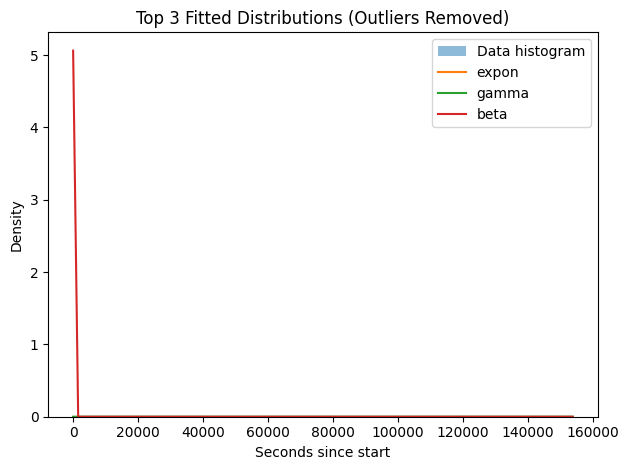

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

# Example list of datetime objects (assumed to be defined elsewhere)
datetimes = sorted(start_times)

# Convert datetimes to numeric values (e.g., seconds since the first datetime)
time_deltas = np.array([
    (datetimes[i] - datetimes[i - 1]).total_seconds()
    for i in range(1, len(datetimes))
])

# --- Outlier removal using Z-score ---
z_scores = np.abs(stats.zscore(time_deltas))
threshold = 3
filtered_deltas = time_deltas[z_scores < threshold]

# List of distributions to test
distributions = ['norm', 'expon', 'lognorm', 'gamma', 'beta']
results = []

# Fit each distribution and compute the Kolmogorov-Smirnov (KS) statistic
x = np.linspace(min(filtered_deltas), max(filtered_deltas), 100)
hist_vals, bin_edges = np.histogram(filtered_deltas, bins=5, density=True)

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    params = dist.fit(filtered_deltas)
    ks_stat, ks_pvalue = stats.kstest(filtered_deltas, dist_name, args=params)
    
    results.append({
        'distribution': dist_name,
        'params': params,
        'ks_stat': ks_stat,
        'ks_pvalue': ks_pvalue
    })

# Sort by KS statistic (lower is better)
results.sort(key=lambda r: r['ks_stat'])

# Plot the histogram and best 3 fitted PDFs
plt.hist(filtered_deltas, bins=5, density=True, alpha=0.5, label='Data histogram')

for result in results[:3]:
    dist = getattr(stats, result['distribution'])
    pdf = dist.pdf(x, *result['params'])
    plt.plot(x, pdf, label=f"{result['distribution']}")

plt.xlabel('Seconds since start')
plt.ylabel('Density')
plt.legend()
plt.title("Top 3 Fitted Distributions (Outliers Removed)")
plt.tight_layout()

results[:3]  # Show the best 3 fits


In [27]:
mu = 20203198.389895137/3600
sigma = 10528412.75221794/3600  # standard deviation
n_samples = 1000            # number of data points

# Generate samples
data = np.random.normal(loc=mu, scale=sigma, size=10)
data

array([7702.83123012, 4605.9268809 , 9312.88647799, 7711.38348893,
       3072.23204131, 6945.64118046, 9742.59145577, 5602.31319971,
       8572.07812441, 8335.26855811])

In [29]:
36028/3600

10.007777777777777